In [1]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('working from:', ROOT.name)

working from: project


In [2]:
import yfinance as yf
import pandas as pd

data = yf.download("SPY", start="2015-01-01", end="2026-08-01", progress=False)

# Flatten the MultiIndex columns down to simple names
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print(data.shape)
print(data.head())

(2911, 5)
Price            Close        High         Low        Open     Volume
Date                                                                 
2015-01-02  169.687836  170.885565  168.655319  170.472558  121465900
2015-01-05  166.623337  168.812266  166.317716  168.647066  169632600
2015-01-06  165.053986  167.449419  164.261007  166.929027  209151400
2015-01-07  167.110657  167.449325  165.929464  166.375506  125346700
2015-01-08  170.076096  170.290867  168.498420  168.514931  147217800


In [3]:
data.to_csv(ROOT / "data" / "raw" / "spy_raw.csv")
print(f"Saved {len(data)} rows to data/raw/spy_raw.csv")

Saved 2911 rows to data/raw/spy_raw.csv


Data Source & Validation
Source: Yahoo Finance, via the yfinance Python library (API pull, no manual download or key required)
Ticker: SPY
Date range: 2015-01-01 to 2026-08-01
Rows: 2,911
Validation: no missing values found (see check below); date range and row count consistent with expected trading days over this period

In [4]:
print("Missing values per column:")
print(data.isnull().sum())

Missing values per column:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [5]:
from dotenv import load_dotenv
load_dotenv()

import sys
sys.path.append(str(ROOT / "src"))
from utils import save_raw_data, load_raw_data

# Save using the new env-driven function
save_raw_data(data, "spy_raw.csv")

# Reload to confirm it round-trips correctly
reloaded = load_raw_data("spy_raw.csv")
print(reloaded.head())

Saved 2911 rows to data/raw/spy_raw.csv
Loaded 2911 rows from data/raw/spy_raw.csv
                 Close        High         Low        Open     Volume
Date                                                                 
2015-01-02  169.687836  170.885565  168.655319  170.472558  121465900
2015-01-05  166.623337  168.812266  166.317716  168.647066  169632600
2015-01-06  165.053986  167.449419  164.261007  166.929027  209151400
2015-01-07  167.110657  167.449325  165.929464  166.375506  125346700
2015-01-08  170.076096  170.290867  168.498420  168.514931  147217800


In [6]:
sys.path.append(str(ROOT / "src"))
from cleaning import preprocess_pipeline

raw = load_raw_data("spy_raw.csv")
processed = preprocess_pipeline(raw)

processed.to_csv(ROOT / "data" / "processed" / "spy_processed.csv")
print(f"Saved {len(processed)} processed rows")
print(processed.head())

Loaded 2911 rows from data/raw/spy_raw.csv
Removed 0 duplicate rows
Filled 0 missing values via forward-fill
Saved 2911 processed rows
                 Close        High         Low        Open     Volume
Date                                                                 
2015-01-02  169.687836  170.885565  168.655319  170.472558  121465900
2015-01-05  166.623337  168.812266  166.317716  168.647066  169632600
2015-01-06  165.053986  167.449419  164.261007  166.929027  209151400
2015-01-07  167.110657  167.449325  165.929464  166.375506  125346700
2015-01-08  170.076096  170.290867  168.498420  168.514931  147217800


Preprocessing assumptions: Missing values are forward-filled, assuming the last known price holds until new data arrives (standard for financial time series, avoids fabricating values). Duplicate dates are dropped, keeping the first occurrence. Data is sorted chronologically to support time-series modeling in later stages.

In [7]:
sys.path.append(str(ROOT / "src"))
from outliers import detect_outliers_zscore, remove_outliers

flagged = detect_outliers_zscore(processed)
print(flagged[flagged["is_outlier"]][["Close"]])

Flagged 39 outliers out of 2911 rows (1.34%)
                 Close
Date                  
2015-08-24  157.992935
2015-08-26  162.128311
2016-06-24  173.122513
2018-02-05  231.705292
2018-02-08  226.174454
2018-12-26  220.227615
2020-02-24  293.892090
2020-02-27  271.186096
2020-03-02  281.741547
2020-03-04  285.177948
2020-03-05  275.698181
2020-03-09  249.965927
2020-03-10  262.900421
2020-03-11  250.084351
2020-03-12  226.157089
2020-03-13  245.490402
2020-03-16  218.627914
2020-03-17  230.432129
2020-03-18  218.764648
2020-03-20  209.781998
2020-03-24  222.939209
2020-03-26  239.488892
2020-04-01  225.689865
2020-04-06  242.844650
2020-06-11  275.623199
2020-09-03  318.074554
2020-10-28  302.030060
2022-04-29  388.862976
2022-05-05  390.571381
2022-05-18  369.854004
2022-06-13  353.940826
2022-06-16  346.059662
2022-08-26  384.201141
2022-09-13  372.627106
2022-11-10  375.671173
2025-04-03  529.253784
2025-04-04  498.269684
2025-04-09  541.008423
2025-04-10  517.301941


In [8]:
sys.path.append(str(ROOT / "src"))
from eda import eda_summary
import matplotlib.pyplot as plt

summary_stats = eda_summary(processed)

mean_price: 354.620123
median_price: 317.637268
std_price: 158.715465
min_price: 154.161591
max_price: 757.618225
missing_values: 0
mean_daily_return: 0.000571
std_daily_return: 0.011097
skewness_returns: -0.307509


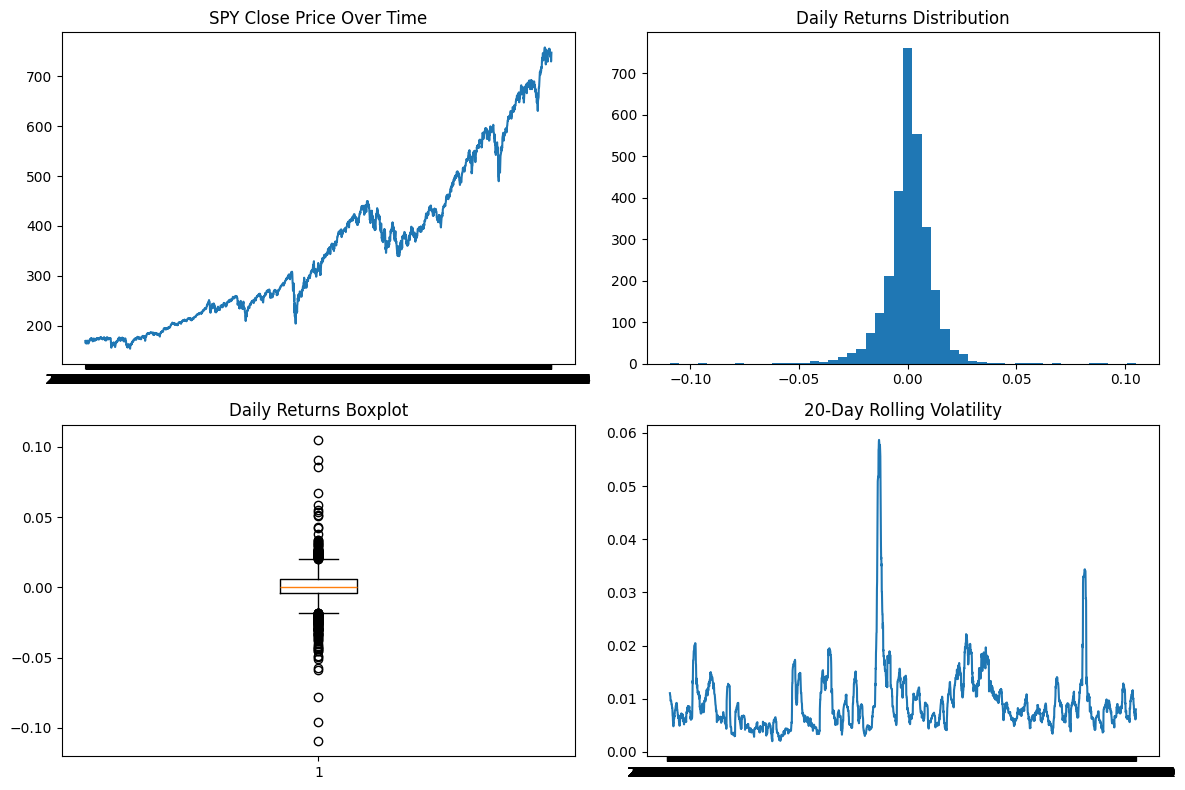

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Time series
axes[0, 0].plot(processed.index, processed["Close"])
axes[0, 0].set_title("SPY Close Price Over Time")

# Returns histogram
returns = processed["Close"].pct_change().dropna()
axes[0, 1].hist(returns, bins=50)
axes[0, 1].set_title("Daily Returns Distribution")

# Boxplot - shows outliers visually
axes[1, 0].boxplot(returns)
axes[1, 0].set_title("Daily Returns Boxplot")

# Rolling volatility (bonus insight, cheap to add)
rolling_vol = returns.rolling(20).std()
axes[1, 1].plot(processed.index[1:], rolling_vol)
axes[1, 1].set_title("20-Day Rolling Volatility")

plt.tight_layout()
plt.savefig(ROOT / "reports" / "images" / "eda_summary.png")
plt.show()

In [10]:
sys.path.append(str(ROOT / "src"))
from features import build_features

featured = build_features(processed)
featured.to_csv(ROOT / "data" / "processed" / "spy_features.csv")
print(f"Built {len(featured)} rows with {featured.shape[1]} columns")
print(featured.columns.tolist())
print(featured.head())

Built 2891 rows with 12 columns
['Close', 'High', 'Low', 'Open', 'Volume', 'ma_5', 'ma_10', 'ma_20', 'momentum', 'volatility', 'rsi', 'target']
                 Close        High         Low        Open     Volume  \
Date                                                                    
2015-02-02  166.788528  166.879390  163.434918  165.243888  163107000   
2015-02-03  169.200485  169.208753  167.308921  167.680624  124212900   
2015-02-04  168.556259  169.646603  168.101949  168.440618  134306700   
2015-02-05  170.257782  170.406471  169.142672  169.217010   97953200   
2015-02-06  169.786972  171.182936  169.266580  170.621241  125672000   

                  ma_5       ma_10       ma_20  momentum  volatility  \
Date                                                                   
2015-02-02  166.233444  167.507166  167.190811  0.239563    0.011050   
2015-02-03  166.580377  167.736797  167.319669  2.296310    0.010766   
2015-02-04  167.227979  167.817747  167.494782  0.809509

In [11]:
sys.path.append(str(ROOT / "src"))
from model import run_walk_forward, FEATURE_COLS

logistic_results = run_walk_forward(featured, model_type="logistic")
rf_results = run_walk_forward(featured, model_type="random_forest")

print("Logistic Regression - walk-forward results:")
print(logistic_results)
print(f"\nMean accuracy: {logistic_results['accuracy'].mean():.4f}")

print("\nRandom Forest - walk-forward results:")
print(rf_results)
print(f"\nMean accuracy: {rf_results['accuracy'].mean():.4f}")

Logistic Regression - walk-forward results:
   accuracy  precision    recall  n_test  fold
0  0.528067   0.552279  0.774436     481     1
1  0.538462   0.597360  0.644128     481     2
2  0.525988   0.525988  1.000000     481     3
3  0.544699   0.544699  1.000000     481     4
4  0.563410   0.563410  1.000000     481     5

Mean accuracy: 0.5401

Random Forest - walk-forward results:
   accuracy  precision    recall  n_test  fold
0  0.490644   0.574468  0.304511     481     1
1  0.440748   0.611111  0.117438     481     2
2  0.480249   1.000000  0.011858     481     3
3  0.498960   0.552239  0.423664     481     4
4  0.440748   0.555556  0.036900     481     5

Mean accuracy: 0.4703


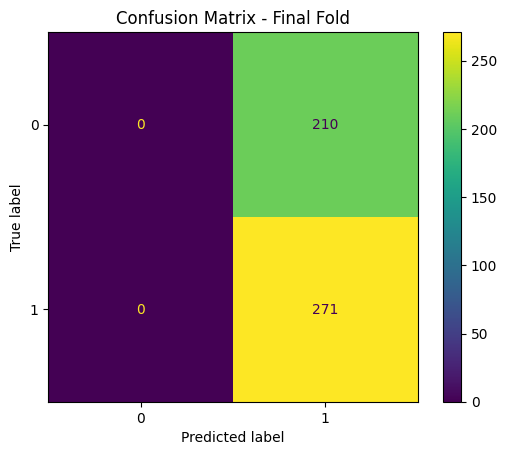

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from model import build_pipeline, walk_forward_split

# Refit on the last fold for a concrete diagnostic view
last_train, last_test = walk_forward_split(featured, n_splits=5)[-1]
pipeline = build_pipeline("logistic")
pipeline.fit(last_train[FEATURE_COLS], last_train["target"])
preds = pipeline.predict(last_test[FEATURE_COLS])

ConfusionMatrixDisplay.from_predictions(last_test["target"], preds)
plt.title("Confusion Matrix - Final Fold")
plt.savefig(ROOT / "reports" / "images" / "confusion_matrix.png")
plt.show()